<img src="logo.png" alt="Vegeta" width="240">

# Drongo — a potato and a cup of cream for hungry people (08b)

Notebook 08 designed a small printed quadcopter. This notebook gives it a job. **Drongo** is notebook 08's quad — the
same `QuadFrame` (250 mm X-frame, PETG-CF), 2306 motors, 5x4.3 three-blade propellers and 4S 1500 mAh battery — with a
landing gear of two skids and a **pincer** under the centre plate (one servo, a pinion between two racks, two jaws with
rubber pads). It fetches a **potato** (200 g, a sphere) and then a **cup of cream** (400 g of 18 % cream in its cup, a
cylinder) from a **basket in the supply zone** by the kitchen and takes them to hungry people 36 m away across the garden, past a hedge — **without
smashing either**. Two variants:

- **drop** — four of the people hold a 2 m × 2 m net at waist height over the drop zone; Drongo hovers over it and lets
  go. The net takes an item falling **at most 5 m** onto it (more tears it). The net itself is **not simulated**: an item
  that reaches its plane inside its square is caught there, and the arrest is an assumed stretch of the net;
- **place** — Drongo lowers each item calmly onto the drop zone (a blanket); it **must touch** the zone before Drongo lets
  go.

**How long do the hungry people wait?** From the order (t = 0, Drongo on its pad by the kitchen door, both items in the
basket) until the cream is with them — the potato comes first, then the cream.

Like notebook 27, nothing is designed or solved here: the airframe and the parts list are notebook 08's; the propulsion is
notebook 08's Boreas export when notebook 08 has been run (`_runs/quadcopter/propeller/quad_5x43.json`: maximum thrust,
electrical power at its operating points) — otherwise **stated assumptions** for a 5-inch rotor (no BEMT here). The flight
is **MuJoCo through Chiron**: the frame, the jaws on their slides and the two items as rigid bodies with friction, the
rotors as thrusts with a spin-up lag and limits (a scene hook), a geometric flight controller and the mission's phases.
Whether an item stays in the jaws, falls into the net or lands gently is decided by the contact forces — a judge (`Watch`)
compares them with each item's limits.

```
1 the order          potato, cream, the net, the garden
2 Drongo             notebook 08's quad + skids + pincer: CAD, mass, thrust and power with each item
3 the pincer         the grip window: enough friction to hold it, not enough to crush it
4 the drop           how high: the net's 5 m and the arrest loads
5 drop variant       MuJoCo: fly, drop into the net, movie
6 place variant      MuJoCo: fly, put down on the zone, movie
7 the wait           how long the hungry people wait, where the time goes, energy
8 faster?            cruise speed, climb and descent rates
9 export
```
Design files: `designs/drongo.py` (CAD), `designs/drongo_robot.py` (numbers, items, propulsion, the Chiron robot, the
rotors), `designs/drongo_controller.py` (flight controller, mission phases), `designs/drongo_scenario.py` (the garden,
the judge, tables, movie). `scenarios/drongo_delivery.py` re-runs both variants and writes the movies.

In [1]:
# DEBUG: test the notebook end to end before the full run. On: FEA and CFD are mocked (vegeta.mock: fixed numbers,
# seconds instead of hours, the result cache off). Turn it on here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute <notebook>.ipynb --output <notebook>-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [2]:
import json, math, shutil, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display
from vegeta import dedalus
from vegeta.dedalus import viz as dviz
sys.path.insert(0, "designs")
import drongo_robot as dr, drongo_controller as dc, drongo_scenario as ds

OUT = Path("_runs/quadcopter_potato"); shutil.rmtree(OUT, ignore_errors=True); OUT.mkdir(parents=True)
MOVIES = Path("output") / "08b_quadcopter_potato"; MOVIES.mkdir(parents=True, exist_ok=True)   # every movie of this notebook
VARIANT_COLOR = {"drop": "#2a78d6", "place": "#eb6834"}          # categorical slots 1-2, the same in every plot
ITEM_COLOR = {"potato": "#1baf7a", "cream": "#4a3aa7"}
ROTOR_COLOR = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 90)

## 1. The order

The two items, with what spoils them. The potato is the user's 200 g sphere: at a tuber's density (≈ 1.08 g/cm³, mostly
water and starch — pl.wikipedia "Ziemniak") that is a 71 mm ball. The cream is a 400 g cup of 18 % cream (the product page
the user gave) in a polypropylene cup with a foil lid, as a 92 × 74 mm cylinder — **check the cup's size against the real
one**. The limits are assumptions, stated here and in `drongo_robot.POTATO` / `CREAM`:

- **squeeze** — the most the pads may press (the potato bruises; the cup's thin wall buckles and the foil seal lifts);
- **impact** — the speed at which it may meet the ground (a potato bruises when dropped more than ~15 cm onto a hard
  surface; the cup bursts from ~30 cm);
- **net arrest** — the load when the net stops it (spread by the soft net; the cream's limit is its lid's seal pressure).

**The supply basket** is an open cube — 0.7 m, walls and floor 15 mm — with both items standing on its floor 0.26 m
apart. Drongo picks each item by landing *inside* the basket over it, so the cube must hold its 0.30 m rotor span with
the other item beside it (and its skids, 158 mm apart, clear of that item).

In [3]:
scene = {v: ds.Scene(v) for v in ds.VARIANTS}
S = scene["drop"]
ITEMS = pd.DataFrame({n: {"shape": it["shape"], "mass [g]": it["mass_kg"] * 1000, "diameter [mm]": it["diameter_m"] * 1000,
                          "height [mm]": it["height_m"] * 1000, "friction on the pads and the grass μ": it["mu"],
                          "squeeze limit [N]": it["squeeze_limit_N"], "impact limit [m/s]": it["impact_limit_m_s"],
                          "= a fall onto a hard floor of [m]": it["impact_limit_m_s"] ** 2 / (2 * dr.G),
                          "net arrest limit [N]": it["catch_limit_N"]} for n, it in dr.ITEMS.items()})
display(ITEMS.round(3))
GARDEN = pd.Series({"kitchen pad to the drop zone [m]": round(S.distance_m, 1), "cruise altitude (the frame) [m]": S.cruise_alt,
                    "supply basket": f"open cube {S.basket_size} m, walls and floor {S.basket_wall * 1000:.0f} mm, at x = {S.basket_at[0]} m",
                    "items in the basket [m apart]": round(abs(S.potato_at[1] - S.cream_at[1]), 2),
                    "hedge on the way": f"{S.hedge_height} m high at x = {S.hedge_x} m",
                    "drop zone": f"{S.zone_size} × {S.zone_size} m blanket",
                    "net (drop)": f"{S.net_size} × {S.net_size} m, held {S.net_height} m above the zone",
                    "the net takes a fall of at most [m]": S.net_max_drop, "the net gives (arrest distance) [m]": dr.NET["stretch_m"]},
                   name="the garden")
GARDEN.to_frame()

,potato,cream
shape,sphere,cylinder
mass [g],200.0,412.0
diameter [mm],70.718961,92.0
height [mm],70.718961,74.0
friction on the pads and the grass μ,0.6,0.5
squeeze limit [N],60.0,25.0
impact limit [m/s],1.7,2.4
= a fall onto a hard floor of [m],0.147299,0.293578
net arrest limit [N],60.0,100.0


,the garden
kitchen pad to the drop zone [m],36.5
cruise altitude (the frame) [m],8.0
supply basket,"open cube 0.7 m, walls and floor 15 mm, at x = 1.5 m"
items in the basket [m apart],0.26
hedge on the way,2.5 m high at x = 18.0 m
drop zone,2.4 × 2.4 m blanket
net (drop),"2.0 × 2.0 m, held 1.0 m above the zone"
the net takes a fall of at most [m],5.0
the net gives (arrest distance) [m],0.4


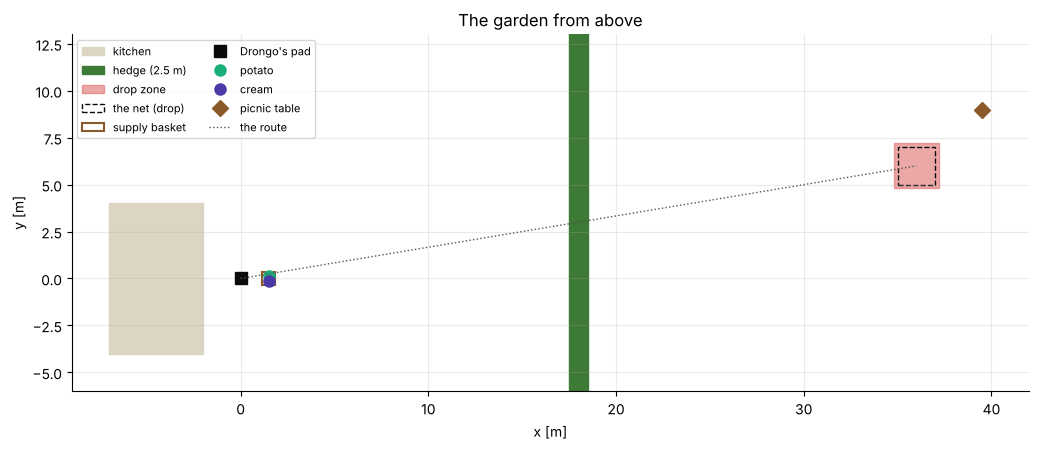

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.6))
zx, zy = S.zone
ax.add_patch(plt.Rectangle((S.home[0] - 7, -4), 5, 8, color="#ddd5c4", label="kitchen"))
ax.add_patch(plt.Rectangle((S.hedge_x - 0.5, (S.home[1] + zy) / 2 - 12), 1, 24, color="#3d7a35", label="hedge (2.5 m)"))
ax.add_patch(plt.Rectangle((zx - S.zone_size / 2, zy - S.zone_size / 2), S.zone_size, S.zone_size, color="#d9534f", alpha=0.5, label="drop zone"))
ax.add_patch(plt.Rectangle((zx - S.net_size / 2, zy - S.net_size / 2), S.net_size, S.net_size, fill=False, ls="--", color=INK, label="the net (drop)"))
ax.add_patch(plt.Rectangle((S.basket_at[0] - S.basket_size / 2, S.basket_at[1] - S.basket_size / 2), S.basket_size, S.basket_size,
                           fill=False, color="#8a5a2b", lw=1.5, label="supply basket"))
ax.plot(*S.home, "s", color=INK, ms=9, label="Drongo's pad")
for n in ("potato", "cream"):
    ax.plot(*S.item_at(n), "o", color=ITEM_COLOR[n], ms=8, label=n)
ax.plot(*S.table[:2], "D", color="#8a5a2b", ms=8, label="picnic table")
ax.plot([S.home[0], zx], [S.home[1], zy], color=MUTED, lw=1, ls=":", label="the route")
ax.set_aspect("equal"); ax.set(xlabel="x [m]", ylabel="y [m]", title="The garden from above", xlim=(-9, 42), ylim=(-6, 13))
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()

## 2. Drongo

Notebook 08's quad as it is — its `QuadFrame` at the default parameters and its parts list — plus what the job needs
(`designs/drongo.py`, `Drongo(QuadFrame)`):

- **skids** 120 mm under the frame, so it can land over an item 75 mm tall with 14 mm to spare under the rail;
- **a pincer**: one 20 g metal-gear servo (the catalogue's `micro-metal 20 g`) turns a 12 mm pinion between two racks; the
  jaws slide apart and together on a rail along x. Their TPU pads sit **36.5 mm above the ground when Drongo stands on its
  skids** — the items' middle — so Drongo lands over an item, closes the jaws on it and lifts it, and when it is lowered
  again the item stands on the ground before the skids do.

One pinion between two racks gives each rack `τ / (2 r)` when both press: **23 N at the servo's stall**, below the cup's
25 N — even a servo stuck at stall cannot crush the cream.

Drongo: 304 × 304 × 156 mm (propeller discs included)


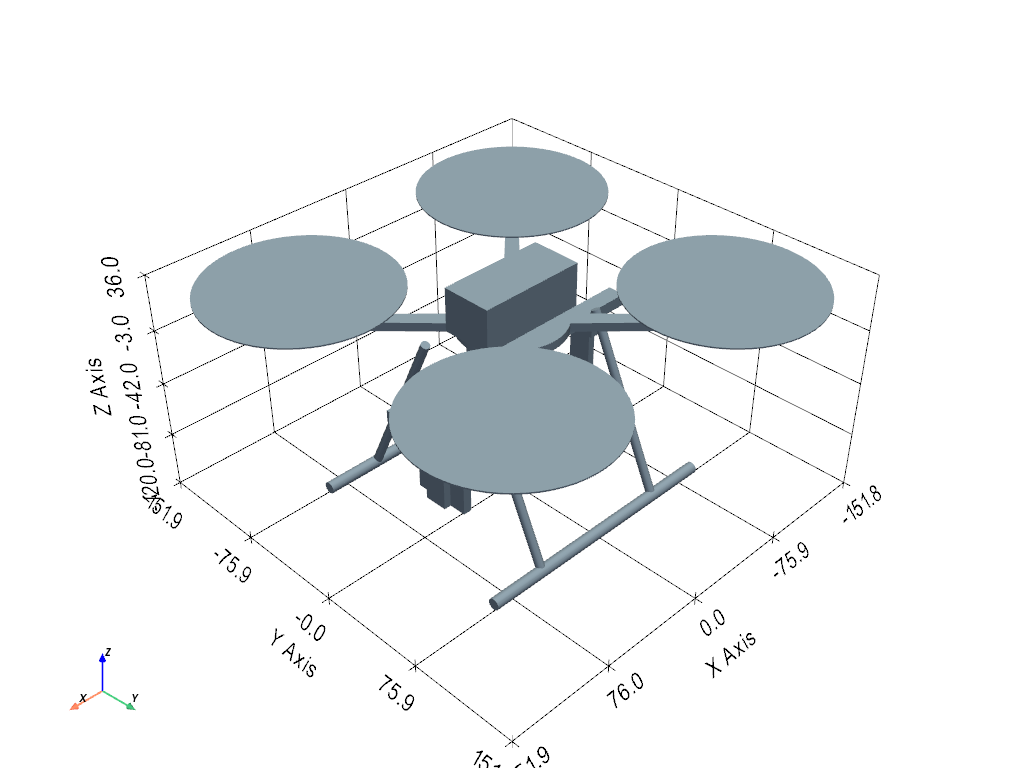

In [5]:
design = dedalus.load_design("designs/drongo.py:Drongo")
drongo_cad = design.generate()
print(f"Drongo: {drongo_cad.dimensions[0]:.0f} × {drongo_cad.dimensions[1]:.0f} × {drongo_cad.dimensions[2]:.0f} mm (propeller discs included)")
dviz.show(dviz.plot3d(drongo_cad, show_edges=False))

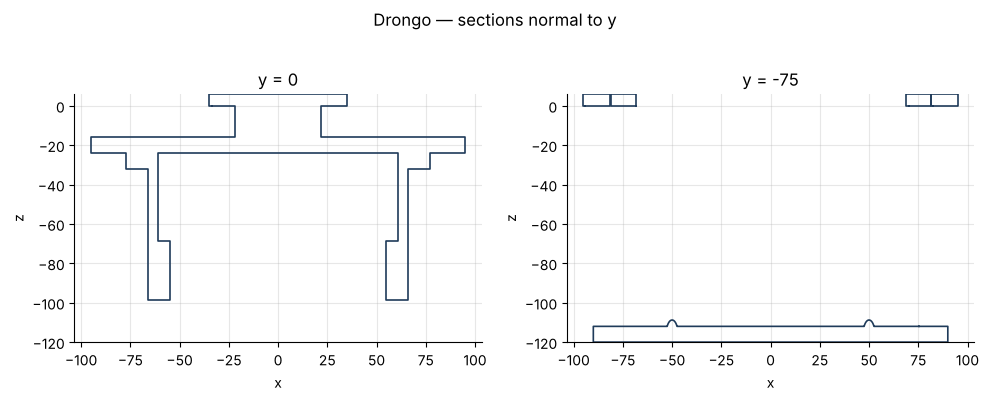

In [6]:
fig = dviz.plot_sections(design.generate(show_bought=False), normal="y", positions=[0.0, -75.0], cols=2)   # through the jaws; through a skid

In [7]:
budget = pd.Series(dr.mass_budget(), name="mass [g]")
notebook_08 = sum(dr.PARTS_G.values()) + budget["frame (QuadFrame, PETG-CF, CAD)"]
print(f"Drongo {budget.sum():.0f} g — notebook 08's quad {notebook_08:.0f} g + {budget.sum() - notebook_08:.0f} g of landing gear and pincer")
budget.round(1).to_frame()

Drongo 587 g — notebook 08's quad 481 g + 106 g of landing gear and pincer


,mass [g]
motors 2306 (4x),120.0
propellers 5x4.3 (4x),20.0
4-in-1 ESC,15.0
flight controller,10.0
battery 4S 1500 mAh,180.0
camera + VTX + antenna,35.0
"receiver, wiring, bolts",30.0
"frame (QuadFrame, PETG-CF, CAD)",71.3
"landing gear (PETG-CF, CAD)",24.1
"servo housing and rail (PETG-CF, CAD)",18.5


**The propulsion.** Notebook 08's export when it exists; here are the numbers the flight uses, and what each item does to
the hover (all four rotors at the same thrust, still air).

In [8]:
PROP = dr.propulsion()
print("propulsion:", PROP.source)
display(pd.Series(PROP.table()).to_frame("value"))
m0 = sum(dr.mass_budget().values()) / 1000
rows = {}
for label, m_item in (("empty", 0.0), ("with the potato", dr.POTATO["mass_kg"]), ("with the cream", dr.CREAM["mass_kg"])):
    m = m0 + m_item
    T = m * dr.G / 4
    P = 4 * float(PROP.electrical_power(T))
    rows[label] = {"all-up mass [g]": m * 1000, "thrust-to-weight": 4 * PROP.max_thrust_N / (m * dr.G),
                   "hover thrust per rotor [N]": T, "share of the maximum": T / PROP.max_thrust_N,
                   "hover power [W]": P, "hover endurance [min]": PROP.usable_Wh / P * 60}
HOVER = pd.DataFrame(rows).T
HOVER.round(2)

propulsion: assumed: a 5-inch 2306 2400KV 4S test-stand class; notebook 08's maximum thrust


,value
max thrust per rotor [N],8.0
spin-up time constant [s],0.035
drag torque / thrust [m],0.011
battery [Wh],22.2
usable [Wh],17.76
source,assumed: a 5-inch 2306 2400KV 4S test-stand class; notebook 08's maximum thrust


,all-up mass [g],thrust-to-weight,hover thrust per rotor [N],share of the maximum,hover power [W],hover endurance [min]
empty,586.92,5.56,1.44,0.18,101.00,10.55
with the potato,786.92,4.15,1.93,0.24,156.13,6.83
with the cream,998.92,3.27,2.45,0.31,219.80,4.85


## 3. The pincer — enough grip to hold it, not enough to crush it

Two pads hold an item by friction. Whatever accelerates it — gravity, a climb, a turn, braking — the pads must carry it
tangentially, so the squeeze per pad must reach `m |g + a| / (2 μ)`. The plan's limits are 3 m/s² sideways (cruise) and
2 m/s² up (climbs); with a safety factor 2 that sets the least squeeze, and the item's squeeze limit (with 1.5) the most.

,potato,cream
least (× 2 at the plan's 3 m/s²) [N],4.06,10.04
chosen [N],6.00,12.00
most (limit / 1.5) [N],40.00,16.67
servo at stall [N],22.92,22.92
the chosen squeeze holds it up to [m/s² sideways],34.64,27.42


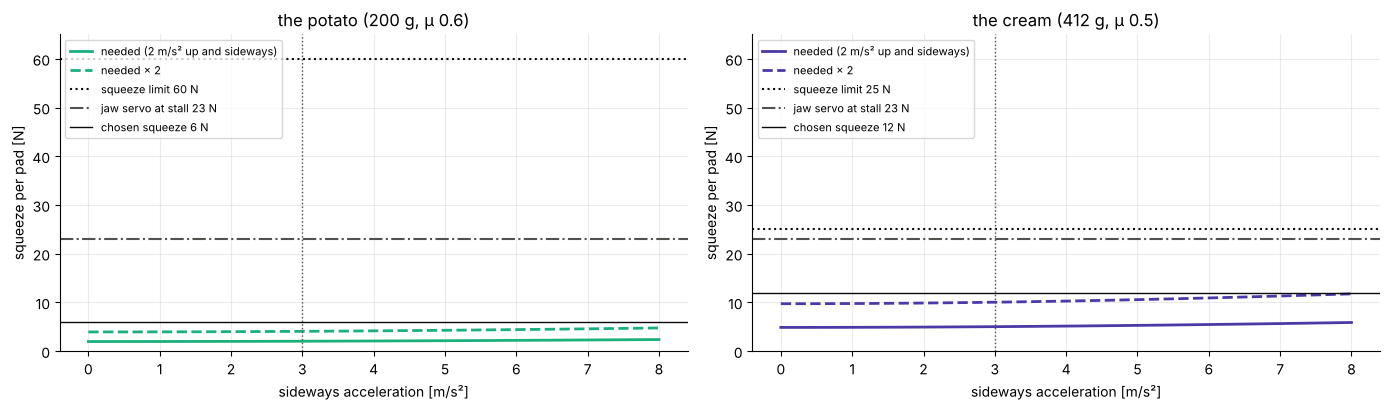

In [9]:
acc = np.linspace(0, 8, 81)
stall = dr.jaw_servo().stall_torque
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
GRIP = {}
for a, (n, it) in zip(ax, dr.ITEMS.items()):
    a.plot(acc, [dr.grip_needed(it, x, 2.0) for x in acc], color=ITEM_COLOR[n], lw=2, label="needed (2 m/s² up and sideways)")
    a.plot(acc, [dr.grip_needed(it, x, 2.0, sf=2.0) for x in acc], color=ITEM_COLOR[n], lw=2, ls="--", label="needed × 2")
    a.axhline(it["squeeze_limit_N"], color=INK, lw=1.5, ls=":", label=f"squeeze limit {it['squeeze_limit_N']:.0f} N")
    a.axhline(stall, color=MUTED, lw=1.5, ls="-.", label=f"jaw servo at stall {stall:.0f} N")
    a.axhline(dr.GRIP_N[n], color=INK, lw=1, label=f"chosen squeeze {dr.GRIP_N[n]:.0f} N")
    a.axvline(dc.Plan().a_cruise, color=MUTED, lw=1, ls=":")
    a.set(xlabel="sideways acceleration [m/s²]", ylabel="squeeze per pad [N]", title=f"the {n} ({it['mass_kg'] * 1000:.0f} g, μ {it['mu']})", ylim=(0, 65))
    a.legend(fontsize=8, loc="upper left")
    GRIP[n] = {"least (× 2 at the plan's 3 m/s²) [N]": dr.grip_needed(it, 3.0, 2.0, sf=2.0), "chosen [N]": dr.GRIP_N[n],
               "most (limit / 1.5) [N]": it["squeeze_limit_N"] / 1.5, "servo at stall [N]": stall,
               "the chosen squeeze holds it up to [m/s² sideways]": dr.grip_holds(it, dr.GRIP_N[n])}
fig.tight_layout()
pd.DataFrame(GRIP).round(2)

## 4. The drop — how high?

An item let go above the net falls freely and reaches it at `√(2 g h)`; the net stops it over its stretch (0.4 m assumed),
so the load on the item is `m (g + v² / (2 s))`. The net's own limit — **5 m** — is the user's. The items survive more than
the net does, so **the net decides**: Drongo lets go with the item's bottom **4 m above the net** (1 m of margin for the
release, a gust or the people moving the net). From the cruise altitude, 7 m above the net, it would tear.

,fall [m],speed at the net [m/s],arrest [g],load on the item [N],net holds,item survives
"potato, 4 m",4.0,8.858894,10.0,21.582,True,True
"potato, 5 m",5.0,9.904544,12.5,26.487,True,True
"potato, 7 m",7.0,11.719215,17.5,36.297,False,True
"cream, 4 m",4.0,8.858894,10.0,44.45892,True,True
"cream, 5 m",5.0,9.904544,12.5,54.56322,True,True
"cream, 7 m",7.0,11.719215,17.5,74.77182,False,True


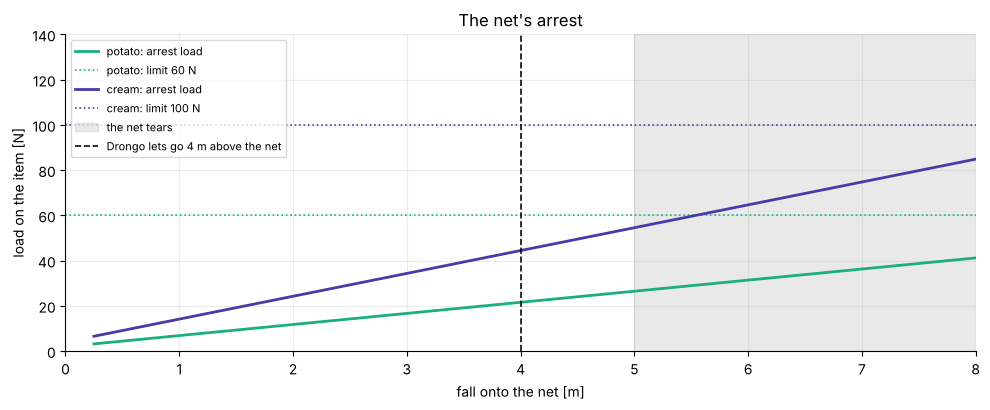

In [10]:
falls = np.linspace(0.25, 8.0, 64)
fig, ax = plt.subplots(figsize=(10, 4.2))
for n, it in dr.ITEMS.items():
    ax.plot(falls, [dr.net_catch(it, h)["load on the item [N]"] for h in falls], color=ITEM_COLOR[n], lw=2, label=f"{n}: arrest load")
    ax.axhline(it["catch_limit_N"], color=ITEM_COLOR[n], lw=1.2, ls=":", label=f"{n}: limit {it['catch_limit_N']:.0f} N")
ax.axvspan(S.net_max_drop, falls[-1], color=MUTED, alpha=0.12, label="the net tears")
ax.axvline(dc.Plan().release_above_net, color=INK, lw=1.2, ls="--", label=f"Drongo lets go {dc.Plan().release_above_net:g} m above the net")
ax.set(xlabel="fall onto the net [m]", ylabel="load on the item [N]", title="The net's arrest", xlim=(0, 8), ylim=(0, 140))
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
DROP = pd.DataFrame({f"{n}, {h:g} m": dr.net_catch(it, h) for n, it in dr.ITEMS.items()
                     for h in (dc.Plan().release_above_net, S.net_max_drop, S.cruise_alt - S.net_height)}).T
DROP.round(2)

## 5. Drop variant — into the net

Drongo in MuJoCo (`ds.make_lab`: the robot, the garden, the items, the rotors, the judge) flies the mission
`dc.delivery(scene, plan)`:

take off → hop over the basket → land in it over the potato (the descent stalls on the basket's floor) → grip → climb to 8 m → fly to the zone →
down to the release height → a steady hover → let go → climb → back for the cream → the same → home.

The plan: cruise 6 m/s at 3 m/s², climb 2.5 m/s, descend 2 m/s, the last 0.6 m to a landing at 0.35 m/s.

In [11]:
PLAN = dc.Plan()
eps, labs = {}, {}

def fly(variant, **kw):
    lab = ds.make_lab(scene[variant], log_geoms=True)
    ep = ds.run(lab, scene[variant], PLAN, **kw)
    labs[variant], eps[variant] = lab, ep
    print(f"{variant}: {'DELIVERED' if ep.outcome['success'] else 'FAILED'} — {ep.outcome['detail']}")
    print(f"  {ep.meta['simulated_s']:.0f} s simulated in {ep.meta['wall_time_s']:.0f} s; Drongo home at {ep.log['mission_end']:.1f} s")
    return ep

def events(ep):
    return pd.DataFrame(ep.log["events"], columns=["t [s]", "who", "what"]).round(2)

ep = fly("drop")
events(ep)

drop: DELIVERED — potato caught in the net at 26.3 s; cream caught in the net at 62.9 s
  130 s simulated in 32 s; Drongo home at 82.7 s


,t [s],who,what
0,8.38,potato,in the jaws (squeeze 4.4 / 6.1 N)
1,25.47,potato,falls from 4.98 m (its bottom above the ground)
2,26.30,net,caught the potato after a 3.98 m fall at 8.9 m/s (arrest load 22 N)
3,30.34,potato,taken to the table by the hungry people
4,44.91,cream,in the jaws (squeeze 10.1 / 7.6 N)
5,62.11,cream,falls from 4.98 m (its bottom above the ground)
6,62.94,net,caught the cream after a 3.98 m fall at 8.9 m/s (arrest load 45 N)
7,68.11,cream,taken to the table by the hungry people


In [12]:
ds.deliveries(eps["drop"]).T

,potato,cream
picked up [s],8.376,44.914
delivered [s],26.3,62.94
how,caught in the net,caught in the net
peak squeeze [N],6.383998,13.007554
squeeze limit [N],60.0,25.0
slip in the jaws [mm],6.260237,6.459567
fall onto the net [m],3.976769,3.979071
speed at the net [m/s],8.863943,8.874798
net arrest load [N],21.604373,44.604171
catch limit [N],60.0,100.0


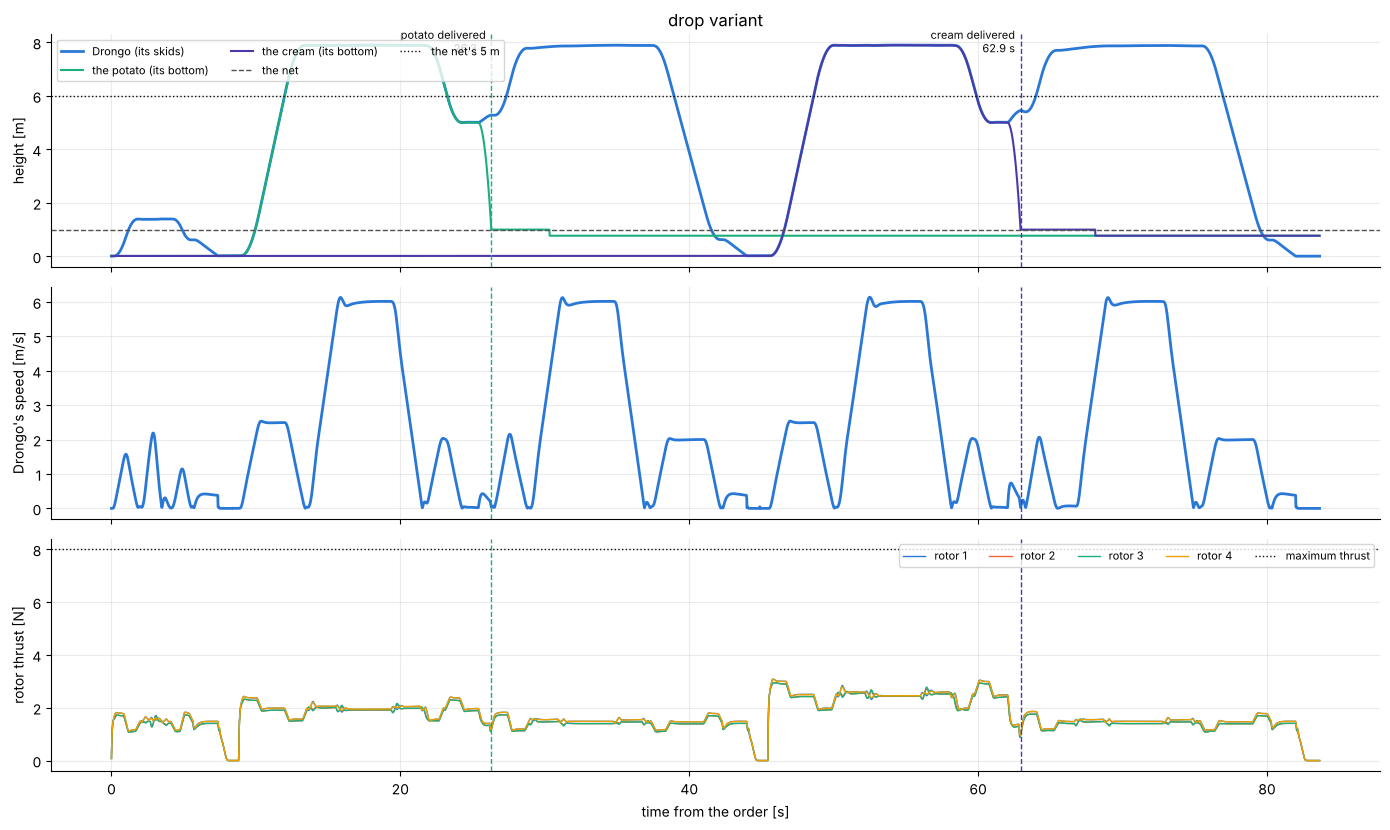

In [13]:
def plot_flight(ep, variant):
    ts = ds.timeseries(ep)
    ts = ts[ts.t <= ep.log["mission_end"] + 1.0]
    recs = ep.log["records"]
    fig, ax = plt.subplots(3, 1, figsize=(14, 8.4), sharex=True)
    ax[0].plot(ts.t, ts.z - dr.geometry()["skid_h"], color=VARIANT_COLOR[variant], lw=2, label="Drongo (its skids)")
    for n in ("potato", "cream"):
        ax[0].plot(ts.t, ts[f"{n}_z"] - dr.ITEMS[n]["height_m"] / 2, color=ITEM_COLOR[n], lw=1.5, label=f"the {n} (its bottom)")
    if variant == "drop":
        ax[0].axhline(S.net_height, color=MUTED, lw=1, ls="--", label="the net")
        ax[0].axhline(S.net_height + S.net_max_drop, color=INK, lw=1, ls=":", label="the net's 5 m")
    ax[0].set(ylabel="height [m]", title=f"{variant} variant")
    ax[1].plot(ts.t, ts.speed, color=VARIANT_COLOR[variant], lw=2)
    ax[1].set(ylabel="Drongo's speed [m/s]")
    for k in range(4):
        ax[2].plot(ts.t, ts[f"T{k + 1}"], color=ROTOR_COLOR[k], lw=1, label=f"rotor {k + 1}")
    ax[2].axhline(PROP.max_thrust_N, color=INK, lw=1, ls=":", label="maximum thrust")
    ax[2].set(ylabel="rotor thrust [N]", xlabel="time from the order [s]")
    for a in ax:
        for n, r in recs.items():
            if r["delivered"] is not None:
                a.axvline(r["delivered"], color=ITEM_COLOR[n], lw=1, ls="--")
    for n, r in recs.items():
        if r["delivered"] is not None:
            ax[0].annotate(f"{n} delivered\n{r['delivered']:.1f} s", (r["delivered"], ax[0].get_ylim()[1] * 0.92), fontsize=8,
                           color=INK, ha="right", xytext=(-4, 0), textcoords="offset points")
    ax[0].legend(fontsize=8, ncol=3, loc="upper left"); ax[2].legend(fontsize=8, ncol=5, loc="upper right")
    fig.tight_layout()

plot_flight(eps["drop"], "drop")

In [14]:
ds.phase_table(eps["drop"], PROP).round(2)

,start [s],duration [s],x [m],y [m],z [m],peak speed [m/s],peak tilt [deg],peak thrust / max,energy [Wh]
01 take off,0.00,1.97,0.03,-0.00,1.51,1.57,1.65,0.23,0.05
02 hop over the potato,1.97,1.83,1.52,0.13,1.52,2.19,26.79,0.21,0.05
03 open the jaws over the potato,3.80,0.30,1.49,0.13,1.52,0.25,6.76,0.20,0.01
04 descend over the potato,4.10,1.55,1.51,0.13,0.74,1.15,1.66,0.23,0.04
05 touch down over the potato,5.65,1.86,1.50,0.13,0.14,0.42,1.17,0.19,0.05
06 spool down over the potato,7.51,0.50,1.50,0.13,0.14,0.00,0.00,0.14,0.00
07 grip the potato,8.01,0.80,1.50,0.13,0.14,0.00,0.00,0.00,0.00
08 climb with the potato,8.81,4.71,1.49,0.13,8.02,2.54,1.47,0.30,0.20
09 fly the potato to the net,13.52,8.14,36.03,6.00,8.02,6.13,24.22,0.28,0.36
10 down to the release height,21.66,2.74,36.05,6.01,5.13,2.04,7.74,0.30,0.12


### The movie

Chiron's renderer (pyvista, from the episode's log) with a chase camera that turns into a wide shot of the zone near the
net, a panel with the hungry people's clock, the phase and what has happened to each item, the outcome on the last frame.
Twice real time. It needs a display (run Jupyter under one, or `xvfb-run -a python3 scenarios/drongo_delivery.py`).

movie: output/08b_quadcopter_potato/drongo_drop.mp4


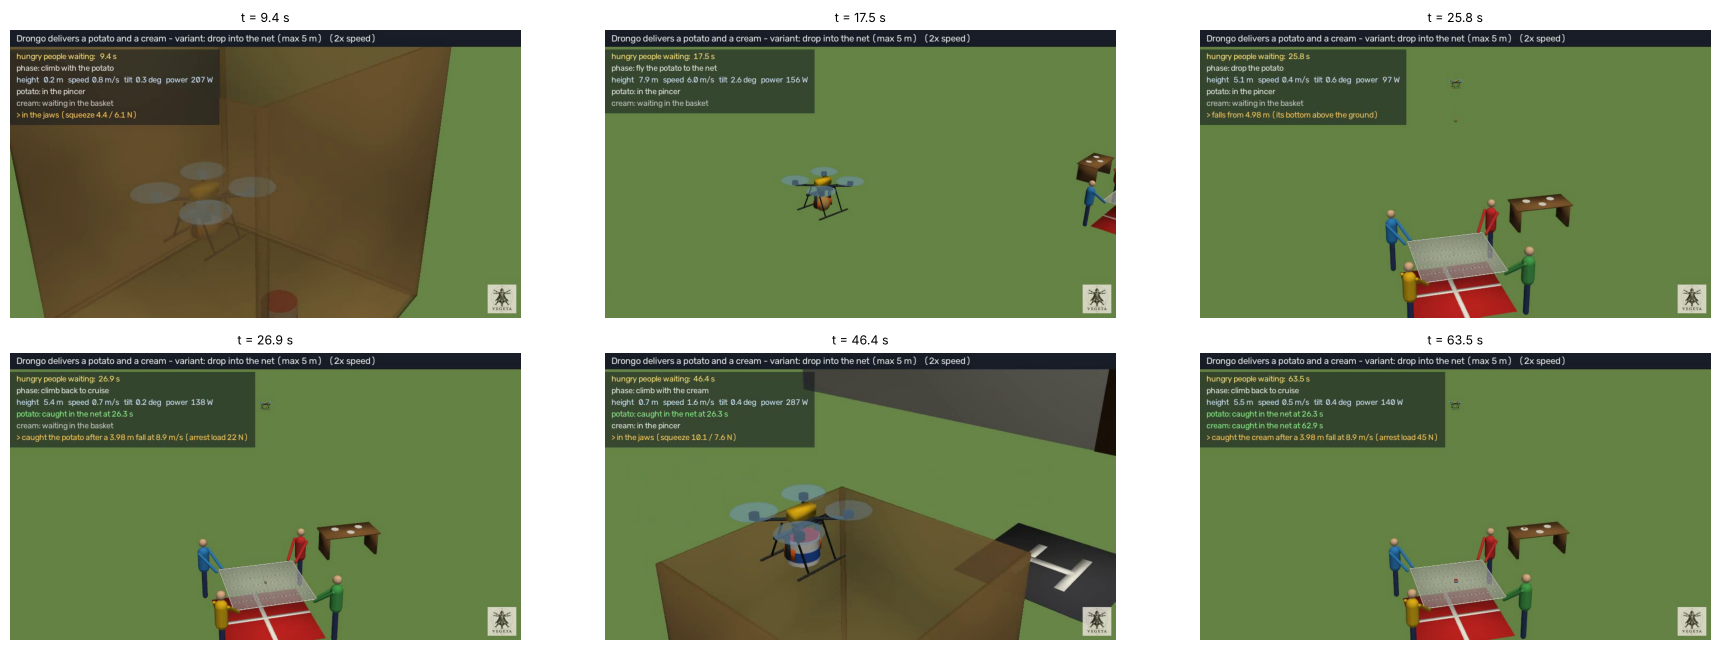

In [15]:
def movie(variant, stills_at):
    try:
        path = ds.render_movie(eps[variant], scene[variant], MOVIES / f"drongo_{variant}.mp4")
    except Exception as exc:                                     # no display here
        print(f"movie not rendered ({type(exc).__name__}: {exc}); run under a display or scenarios/drongo_delivery.py")
        return None
    print(f"movie: {path}")
    display(Video(str(path), embed=False, width=900))
    imgs = ds.stills(path, stills_at)
    fig, ax = plt.subplots(2, 3, figsize=(18, 6.6))
    for a, img, t in zip(ax.flat, imgs, stills_at):
        a.imshow(img); a.set_axis_off(); a.set_title(f"t = {t:.1f} s", fontsize=9)
    fig.tight_layout()
    return path

def moments(ep):
    r, m = ep.log["records"], ep.log["mission"]
    first = lambda key: next(t for t, name, note in m if key in name and note == "start")   # noqa: E731
    return [r["potato"]["picked_up"] + 1.0, first("fly the potato") + 4.0, r["potato"]["released"] + 0.3,
            r["potato"]["delivered"] + 0.6, r["cream"]["picked_up"] + 1.5, r["cream"]["delivered"] + 0.6]

MOVIE = {"drop": movie("drop", moments(eps["drop"]))}

## 6. Place variant — onto the zone

The same flight to the zone; there Drongo descends with the item to 0.6 m and lowers it at **0.25 m/s** until it senses
the touch (its descent stalls: the item stands on the zone — the flight controller's land detector), holds 0.3 s, opens the
jaws and climbs away. It never lands among the people. Each item has its own spot, 0.45 m either side of the zone's
centre; the people take each item to the table once Drongo has left.

In [16]:
ep = fly("place")
events(ep)

place: DELIVERED — potato put down on the zone at 29.5 s; cream put down on the zone at 72.2 s
  130 s simulated in 34 s; Drongo home at 93.6 s


,t [s],who,what
0,8.38,potato,in the jaws (squeeze 4.4 / 6.1 N)
1,28.95,potato,"touches the ground at 0.25 m/s, inside the zone"
2,29.52,potato,let go on the ground inside the zone
3,36.41,potato,taken to the table by the hungry people
4,51.00,cream,in the jaws (squeeze 9.8 / 7.5 N)
5,71.65,cream,"touches the ground at 0.26 m/s, inside the zone"
6,72.22,cream,let go on the ground inside the zone
7,79.11,cream,taken to the table by the hungry people


In [17]:
ds.deliveries(eps["place"]).T

,potato,cream
picked up [s],8.376,50.996
delivered [s],29.522,72.216
how,put down on the zone,put down on the zone
peak squeeze [N],6.851092,13.080008
squeeze limit [N],60.0,25.0
slip in the jaws [mm],6.260068,6.447134
fall onto the net [m],None,None
speed at the net [m/s],None,None
net arrest load [N],None,None
catch limit [N],None,None


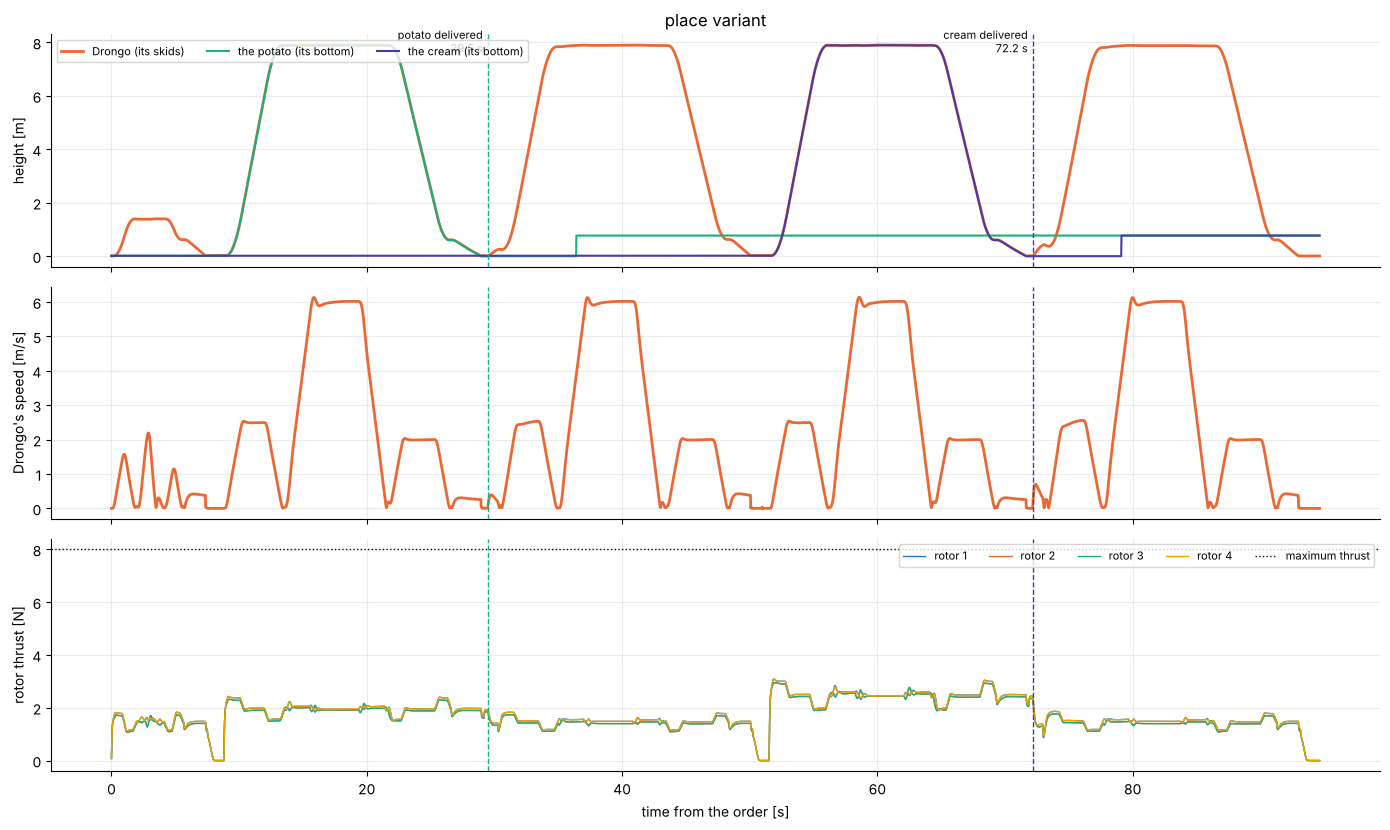

In [18]:
plot_flight(eps["place"], "place")

In [19]:
ds.phase_table(eps["place"], PROP).round(2)

,start [s],duration [s],x [m],y [m],z [m],peak speed [m/s],peak tilt [deg],peak thrust / max,energy [Wh]
01 take off,0.00,1.97,0.03,-0.00,1.51,1.57,1.65,0.23,0.05
02 hop over the potato,1.97,1.83,1.52,0.13,1.52,2.19,26.79,0.21,0.05
03 open the jaws over the potato,3.80,0.30,1.49,0.13,1.52,0.25,6.76,0.20,0.01
04 descend over the potato,4.10,1.55,1.51,0.13,0.74,1.15,1.66,0.23,0.04
05 touch down over the potato,5.65,1.86,1.50,0.13,0.14,0.42,1.17,0.19,0.05
06 spool down over the potato,7.51,0.50,1.50,0.13,0.14,0.00,0.00,0.14,0.00
07 grip the potato,8.01,0.80,1.50,0.13,0.14,0.00,0.00,0.00,0.00
08 climb with the potato,8.81,4.71,1.49,0.13,8.02,2.54,1.47,0.30,0.20
09 fly the potato to the zone,13.52,8.15,36.03,6.45,8.02,6.13,24.22,0.28,0.37
10 descend with the potato to the zone,21.67,4.94,36.03,6.45,0.73,2.04,7.72,0.30,0.21


movie: output/08b_quadcopter_potato/drongo_place.mp4


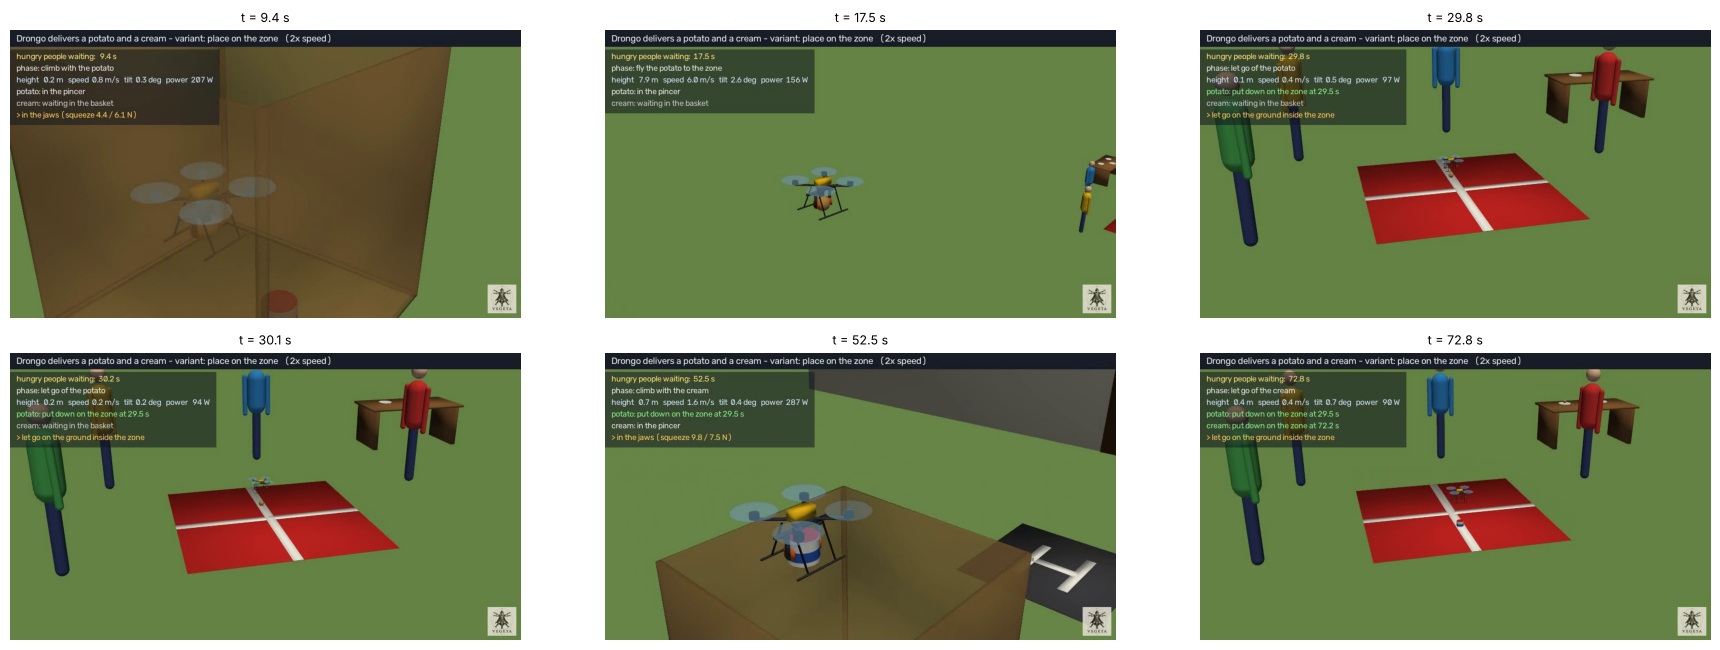

In [20]:
MOVIE["place"] = movie("place", moments(eps["place"]))

## 7. How long do the hungry people wait?

In [21]:
WAIT = pd.DataFrame({v: {**ds.wait_times(ep), "unspoilt": ep.outcome["success"], "energy [Wh]": ep.log["energy_Wh"],
                          "battery used [%]": 100 * ep.log["energy_Wh"] / PROP.usable_Wh,
                          "peak tilt [deg]": ds.timeseries(ep).tilt_deg.max()} for v, ep in eps.items()}).T
for v, r in WAIT.iterrows():
    print(f"{v:>5}: the potato arrives after {r['potato [s]']:.1f} s, the cream after {r['cream [s]']:.1f} s — "
          f"the hungry people wait {r['both [s]']:.1f} s ({r['both [s]'] / 60:.1f} min) for both; "
          f"{'nothing spoilt' if r['unspoilt'] else 'SPOILT'}; {r['battery used [%]']:.0f} % of the battery")
d = WAIT.loc["place", "both [s]"] - WAIT.loc["drop", "both [s]"]
print(f"placing costs {d:.1f} s more than dropping: two slow descents to the ground and back instead of to 5 m")
WAIT.round(2)

 drop: the potato arrives after 26.3 s, the cream after 62.9 s — the hungry people wait 62.9 s (1.0 min) for both; nothing spoilt; 17 % of the battery
place: the potato arrives after 29.5 s, the cream after 72.2 s — the hungry people wait 72.2 s (1.2 min) for both; nothing spoilt; 20 % of the battery
placing costs 9.3 s more than dropping: two slow descents to the ground and back instead of to 5 m


,potato [s],cream [s],both [s],Drongo home [s],unspoilt,energy [Wh],battery used [%],peak tilt [deg]
drop,26.3,62.94,62.94,82.652,True,3.09347,17.418188,26.793158
place,29.522,72.216,72.216,93.642,True,3.588968,20.208154,26.793158


**Where the time goes**, phase by phase until the cream is with the people: flying (cruise and hops), climbing,
descending and landing, handling the items (jaws, the hover before a drop, the hold before letting go).

,flying,climbing,descending and landing,handling the item,the wait [s]
drop,26.3,14.2,16.7,5.8,62.9
place,26.3,16.1,26.2,3.7,72.2


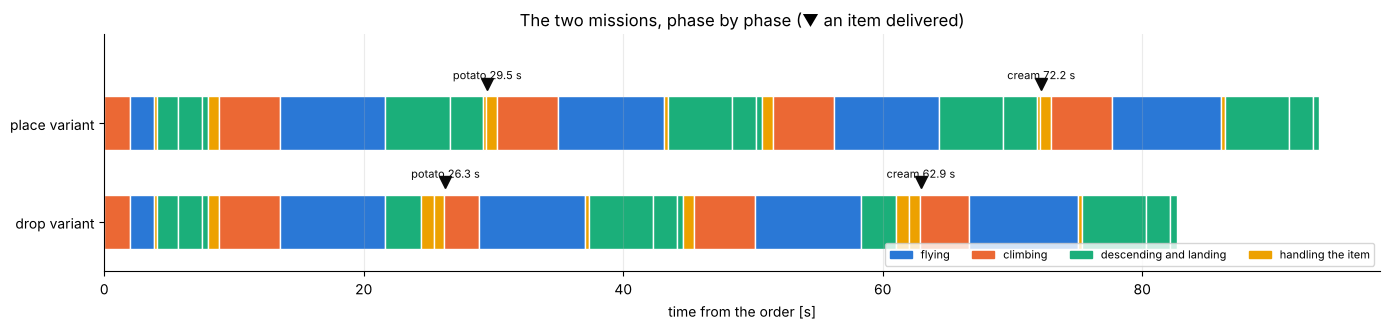

In [22]:
ACT_COLOR = dict(zip(ds.ACTIVITIES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
fig, ax = plt.subplots(figsize=(14, 3.4))
for row, (v, ep) in enumerate(eps.items()):
    starts = [(t, name) for t, name, note in ep.log["mission"] if note == "start"]
    for k, (t0, name) in enumerate(starts):
        t1 = starts[k + 1][0] if k + 1 < len(starts) else ep.log["mission_end"]
        ax.barh(row, t1 - t0, left=t0, height=0.55, color=ACT_COLOR.get(ds.activity(name), MUTED), edgecolor="white", linewidth=1)
    for n, r in ep.log["records"].items():
        ax.plot(r["delivered"], row + 0.4, "v", color=INK, ms=8)
        ax.annotate(f"{n} {r['delivered']:.1f} s", (r["delivered"], row + 0.42), fontsize=8, ha="center", va="bottom", color=INK)
ax.set_yticks(range(len(eps)), [f"{v} variant" for v in eps]); ax.set_ylim(-0.5, len(eps) - 0.1)
ax.set(xlabel="time from the order [s]", title="The two missions, phase by phase (▼ an item delivered)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in ACT_COLOR.values()], labels=list(ACT_COLOR), fontsize=8, ncol=4, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
BUDGET = pd.DataFrame({v: ds.time_budget(ep) for v, ep in eps.items()}).T
BUDGET["the wait [s]"] = BUDGET.sum(axis=1)
BUDGET.round(1)

## 8. Faster?

Could Drongo make them wait less? The same missions in MuJoCo, each a full simulation with the judge (four at a time):

- a faster **cruise**, 4 to 12 m/s (the acceleration rising with it to 4.5 m/s² — inside the grip window of §3: the
  cream's 12 N hold it to 11 m/s² sideways);
- a lower **cruise altitude**: 5.2 m instead of 8 m — just high enough for the drop's release (the item's bottom 5 m up),
  still 2.6 m over the hedge;
- faster **climbs and descents**, 4 m/s up and 3 m/s down instead of 2.5 and 2 (at 6 m/s and 8 m).

In [23]:
SPEEDS = [(4.0, 2.0), (6.0, 3.0), (8.0, 3.5), (10.0, 4.0), (12.0, 4.5)]
PLANS = [{"v_cruise": v, "a_cruise": a, "cruise_alt": h} for h in (8.0, 5.2) for v, a in SPEEDS] + \
        [{"v_cruise": 6.0, "a_cruise": 3.0, "cruise_alt": 8.0, "v_climb": 4.0, "v_descent": 3.0}]
SWEEP = ds.sweep(PLANS, processes=4)
SWEEP["climb / descent [m/s]"] = [f"{c:g} / {d:g}" for c, d in zip(SWEEP["v_climb"].fillna(dc.Plan().v_climb),
                                                                   SWEEP["v_descent"].fillna(dc.Plan().v_descent))]
cols = ["variant", "cruise_alt", "v_cruise", "a_cruise", "climb / descent [m/s]", "potato [s]", "both [s]", "unspoilt",
        "peak tilt [deg]", "energy [Wh]", "flying [s]", "climbing [s]", "descending and landing [s]", "handling the item [s]"]
SWEEP[cols].round(2)

,variant,cruise_alt,v_cruise,a_cruise,climb / descent [m/s],potato [s],both [s],unspoilt,peak tilt [deg],energy [Wh],flying [s],climbing [s],descending and landing [s],handling the item [s]
0,drop,8.0,4.0,2.0,2.5 / 2,29.42,71.90,True,18.75,3.54,35.22,14.18,16.69,5.81
1,place,8.0,4.0,2.0,2.5 / 2,32.65,81.19,True,18.75,4.04,35.24,16.09,26.20,3.67
2,drop,8.0,6.0,3.0,2.5 / 2,26.30,62.94,True,26.79,3.09,26.26,14.18,16.69,5.81
3,place,8.0,6.0,3.0,2.5 / 2,29.52,72.22,True,26.79,3.59,26.27,16.09,26.19,3.67
4,drop,8.0,8.0,3.5,2.5 / 2,25.06,59.35,True,30.28,2.93,22.68,14.18,16.69,5.81
5,place,8.0,8.0,3.5,2.5 / 2,28.27,68.62,True,30.28,3.42,22.68,16.09,26.18,3.67
6,drop,8.0,10.0,4.0,2.5 / 2,24.35,57.31,True,33.14,2.85,20.63,14.18,16.69,5.81
7,place,8.0,10.0,4.0,2.5 / 2,27.55,66.58,True,33.16,3.34,20.64,16.09,26.18,3.67
8,drop,8.0,12.0,4.5,2.5 / 2,24.10,56.41,True,36.61,2.83,19.37,14.18,17.04,5.81
9,place,8.0,12.0,4.5,2.5 / 2,27.13,65.32,True,36.63,3.31,19.38,16.09,26.18,3.67


drop: 62.9 s at 6 m/s and 8 m | 12 m/s: 6.5 s less | climb 4 / descend 3 m/s: 1.7 s less | cruise at 5.2 m: 9.4 s less | 5.2 m and 12 m/s: 46.6 s; all unspoilt: True
place: 72.2 s at 6 m/s and 8 m | 12 m/s: 6.9 s less | climb 4 / descend 3 m/s: 3.4 s less | cruise at 5.2 m: 7.6 s less | 5.2 m and 12 m/s: 57.8 s; all unspoilt: True


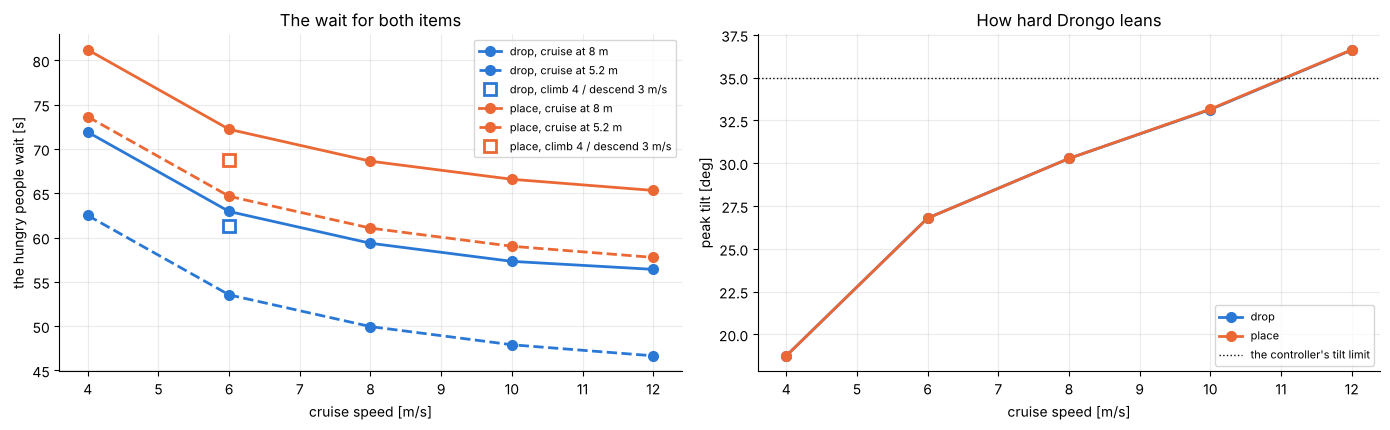

In [24]:
std = SWEEP["climb / descent [m/s]"] == f"{dc.Plan().v_climb:g} / {dc.Plan().v_descent:g}"
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for v in ds.VARIANTS:
    for h, ls in ((8.0, "-"), (5.2, "--")):
        s = SWEEP[std & (SWEEP.variant == v) & (SWEEP.cruise_alt == h)].sort_values("v_cruise")
        ax[0].plot(s.v_cruise, s["both [s]"], "o" + ls, color=VARIANT_COLOR[v], lw=2, ms=7, label=f"{v}, cruise at {h:g} m")
        if h == 8.0:
            ax[1].plot(s.v_cruise, s["peak tilt [deg]"], "o-", color=VARIANT_COLOR[v], lw=2, ms=7, label=v)
    f = SWEEP[~std & (SWEEP.variant == v)]
    ax[0].plot(f.v_cruise, f["both [s]"], "s", color=VARIANT_COLOR[v], ms=9, mfc="white", mew=2, label=f"{v}, climb 4 / descend 3 m/s")
ax[1].axhline(math.degrees(dc.Flight(PROP).tilt_max), color=INK, lw=1, ls=":", label="the controller's tilt limit")
ax[0].set(xlabel="cruise speed [m/s]", ylabel="the hungry people wait [s]", title="The wait for both items")
ax[1].set(xlabel="cruise speed [m/s]", ylabel="peak tilt [deg]", title="How hard Drongo leans")
for a in ax:
    a.legend(fontsize=8)
fig.tight_layout()

def wait(v, h=8.0, vc=6.0, fast_vertical=False):
    sel = (SWEEP.variant == v) & (SWEEP.cruise_alt == h) & (SWEEP.v_cruise == vc) & (std if not fast_vertical else ~std)
    return float(SWEEP[sel]["both [s]"].iloc[0])

for v in ds.VARIANTS:
    w0 = wait(v)
    print(f"{v}: {w0:.1f} s at 6 m/s and 8 m | 12 m/s: {w0 - wait(v, vc=12.0):.1f} s less | climb 4 / descend 3 m/s: "
          f"{w0 - wait(v, fast_vertical=True):.1f} s less | cruise at 5.2 m: {w0 - wait(v, h=5.2):.1f} s less | "
          f"5.2 m and 12 m/s: {wait(v, h=5.2, vc=12.0):.1f} s; all unspoilt: {bool(SWEEP[SWEEP.variant == v].unspoilt.all())}")

**Reading it.** The cruise is only part of the wait: each delivery is a climb and a descent of the full cruise height, a
landing over the item and the work of the jaws. Doubling the cruise speed shortens only the flying, and the 36 m legs are
short — Drongo spends much of each leg accelerating and braking — so the gain is a few seconds while the lean grows to the
controller's limit. Faster climbs and descents gain little for the same reason: 8 m legs are mostly acceleration. What
pays is **flying lower**: at 5.2 m every climb and descent is 2.8 m shorter, and the drop variant then only has to stop
and let go. The drop stays faster than placing at every setting: it hovers at 5 m where placing must descend to the
ground and climb back. Nothing spoilt in any run.

## 9. Export

The order, the plan, the deliveries, the wait and the sweep as one JSON record (`_runs/quadcopter_potato/drongo_delivery.json`).

In [25]:
doc = {"source": "08b_quadcopter_potato", "drongo": {"mass_g": float(budget.sum()), "propulsion": PROP.table()},
       "items": {n: {k: v for k, v in it.items() if k != "rgba"} for n, it in dr.ITEMS.items()}, "net": dr.NET,
       "plan": PLAN.__dict__, "grip": GRIP,
       "variants": {v: {"wait": ds.wait_times(ep), "outcome": ep.outcome, "energy_Wh": ep.log["energy_Wh"],
                        "deliveries": ds.deliveries(ep).reset_index().to_dict("records"), "time_budget": ds.time_budget(ep),
                        "movie": str(MOVIE.get(v))} for v, ep in eps.items()},
       "sweep": SWEEP.drop(columns=["detail"]).to_dict("records")}
(OUT / "drongo_delivery.json").write_text(json.dumps(doc, indent=1, default=lambda o: o.item() if hasattr(o, "item") else str(o)))
print("written", OUT / "drongo_delivery.json")

written _runs/quadcopter_potato/drongo_delivery.json


**Not modelled, next.** The net as a body (a cloth or a spring mesh: where in it the item comes to rest, how the people's
arms give); wind and gusts over the garden, and the rotors' downwash on the net and the people; ground effect near the
pickups; the frame's FEA with the pincer's and the skids' loads (notebook 08's load cases with 0.4 kg hanging below);
real numbers for the cup (its size and the force that crushes it) and for bruising a potato; a lower cruise altitude and a
faster approach to the ground (§8).